In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [3]:
df = pd.read_csv('IBM_HR.csv')
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
print(df.shape)

(1470, 31)


In [4]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='str').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print("Encoding done!")
df.head()

Encoding done!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [5]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1470, 30)
Target shape: (1470,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1176, 30)
Test size: (294, 30)


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaling done!")

Scaling done!


In [8]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {round(accuracy * 100, 2)}%")

Accuracy: 89.46%


In [10]:
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

              precision    recall  f1-score   support

No Attrition       0.91      0.98      0.94       255
   Attrition       0.70      0.36      0.47        39

    accuracy                           0.89       294
   macro avg       0.80      0.67      0.71       294
weighted avg       0.88      0.89      0.88       294



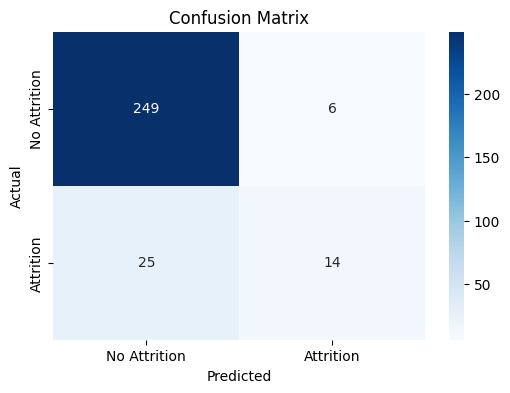

In [11]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x=importance.values, y=importance.index, hue=importance.index, palette='coolwarm', legend=False)
plt.title('Top 10 Features Influencing Attrition')
plt.xlabel('Coefficient Magnitude')
plt.show()

NameError: name 'importance' is not defined

<Figure size 1000x500 with 0 Axes>